###


Loading Internal Data: GUdata3.csv

[Method] LASSO Feature Selection is OFF (Using All Variables).
Using all 23 features.

--- Training Decision Tree ---
The best hyperparameters: {'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}


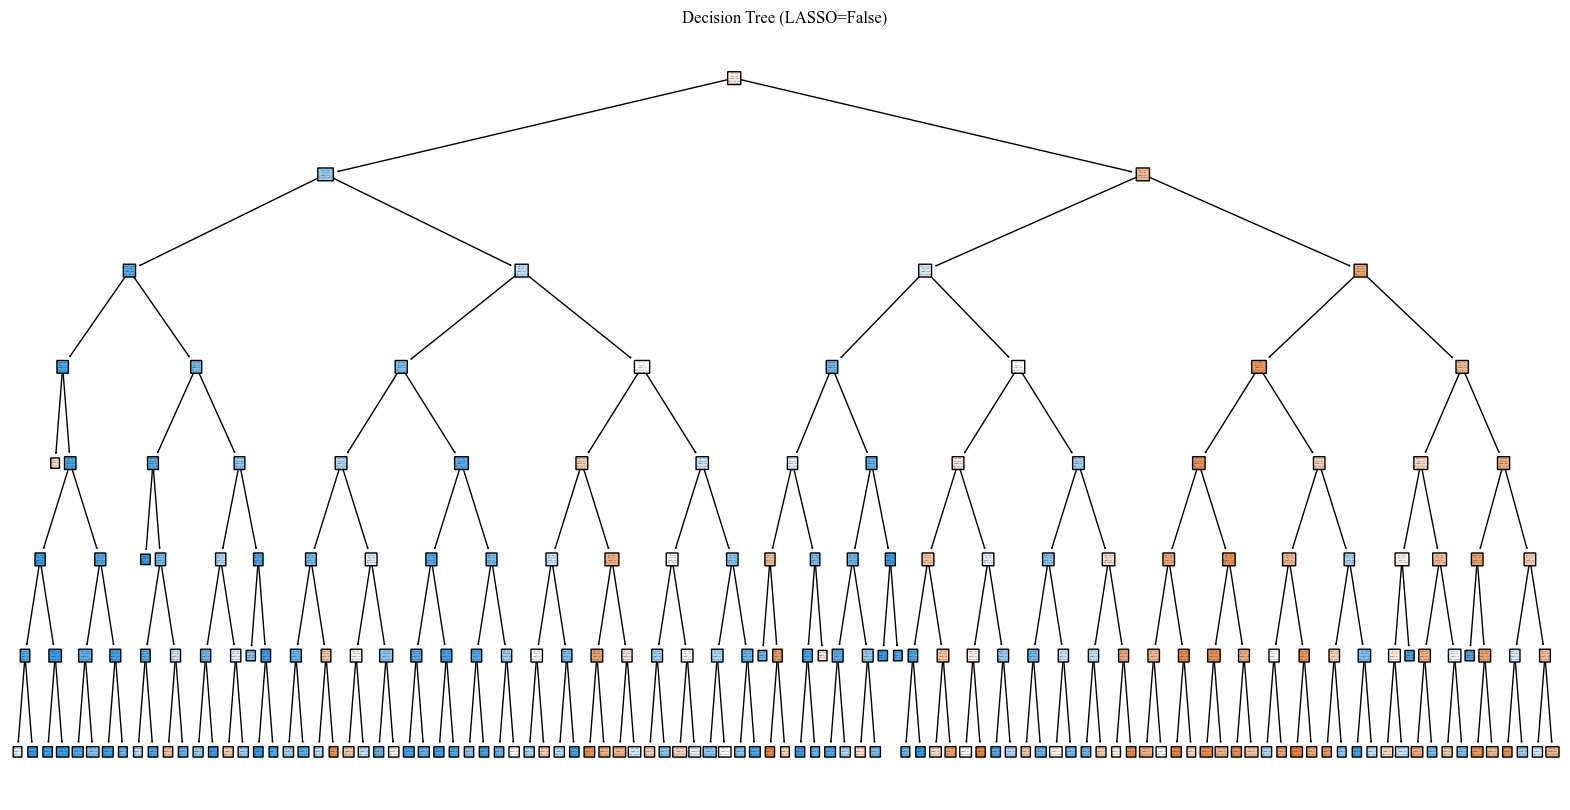

|--- Alb <= 3.65
|   |--- eGFR <= 42.09
|   |   |--- eGFR <= 36.96
|   |   |   |--- MCV <= 71.70
|   |   |   |   |--- class: 0
|   |   |   |--- MCV >  71.70
|   |   |   |   |--- Alb <= 3.05
|   |   |   |   |   |--- Cre <= 1.34
|   |   |   |   |   |   |--- LD <= 188.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- LD >  188.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Cre >  1.34
|   |   |   |   |   |   |--- RDWCV <= 13.35
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- RDWCV >  13.35
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- Alb >  3.05
|   |   |   |   |   |--- Cre <= 1.86
|   |   |   |   |   |   |--- PLT <= 243.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- PLT >  243.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Cre >  1.86
|   |   |   |   |   |   |--- LD <= 424.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- LD >  

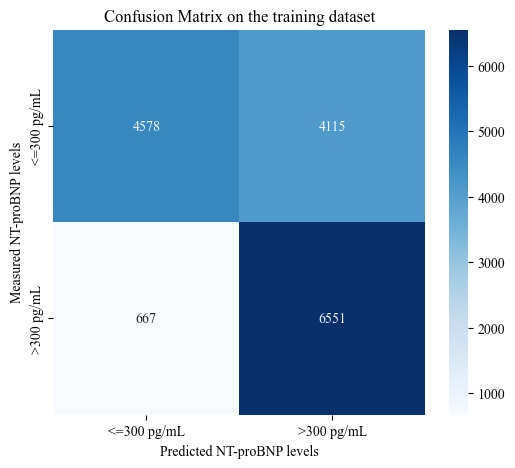

Classification Report (Train):
              precision    recall  f1-score   support

 <=300 pg/mL       0.87      0.53      0.66      8693
  >300 pg/mL       0.61      0.91      0.73      7218

    accuracy                           0.70     15911
   macro avg       0.74      0.72      0.69     15911
weighted avg       0.76      0.70      0.69     15911



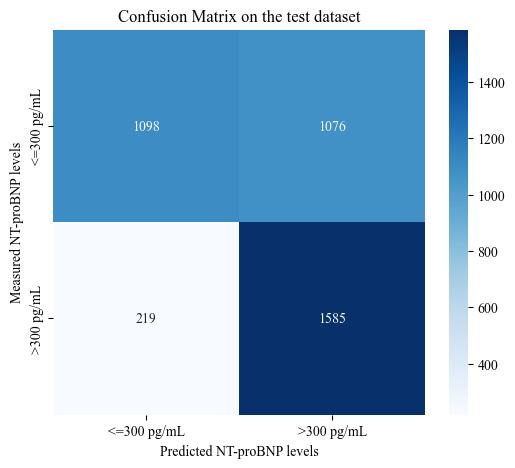

Classification Report (Test):
              precision    recall  f1-score   support

 <=300 pg/mL       0.83      0.51      0.63      2174
  >300 pg/mL       0.60      0.88      0.71      1804

    accuracy                           0.67      3978
   macro avg       0.71      0.69      0.67      3978
weighted avg       0.73      0.67      0.67      3978



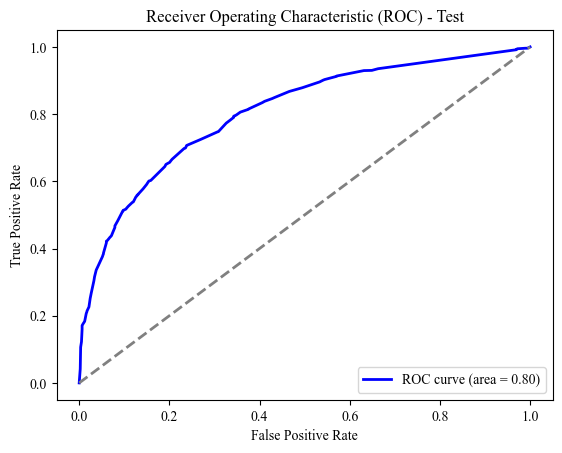


--- External Validation ---


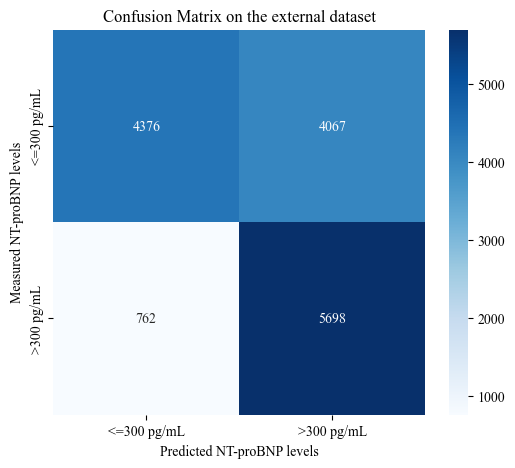

Classification Report (External):
              precision    recall  f1-score   support

 <=300 pg/mL       0.85      0.52      0.64      8443
  >300 pg/mL       0.58      0.88      0.70      6460

    accuracy                           0.68     14903
   macro avg       0.72      0.70      0.67     14903
weighted avg       0.74      0.68      0.67     14903



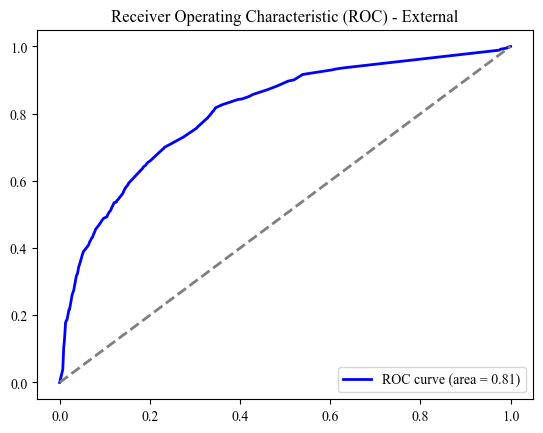


=== Performance Metrics with 95% CIs ===


,Metric,Estimate,95% CI,Cohort
0,AUROC,0.848706,0.843–0.855,Internal Train
1,Sensitivity,0.907592,0.901–0.914,Internal Train
2,Specificity,0.526631,0.516–0.537,Internal Train
3,PPV,0.614195,0.605–0.623,Internal Train
4,NPV,0.872831,0.864–0.882,Internal Train
5,Accuracy,0.699453,0.692–0.707,Internal Train
6,F1,0.732610,0.726–0.740,Internal Train
7,Threshold,0.263158,-,Internal Train
8,AUROC,0.804138,0.791–0.818,Internal Test
9,Sensitivity,0.878603,0.863–0.893,Internal Test


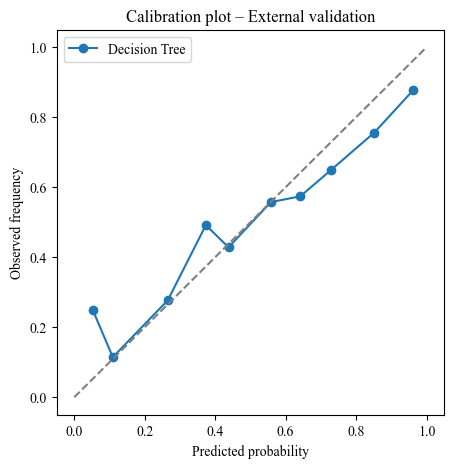

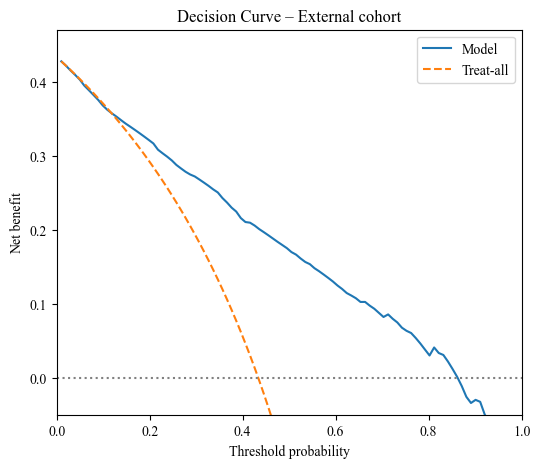


=== Subgroup Analysis (External) ===


,Subgroup,N,AUROC,F1
0,Age < 65,4060,0.793679,0.600829
1,Age >= 65,10843,0.785409,0.722222
2,eGFR < 60,7656,0.779474,0.763561
3,eGFR >= 60,7247,0.777769,0.587631



--- SHAP Analysis ---


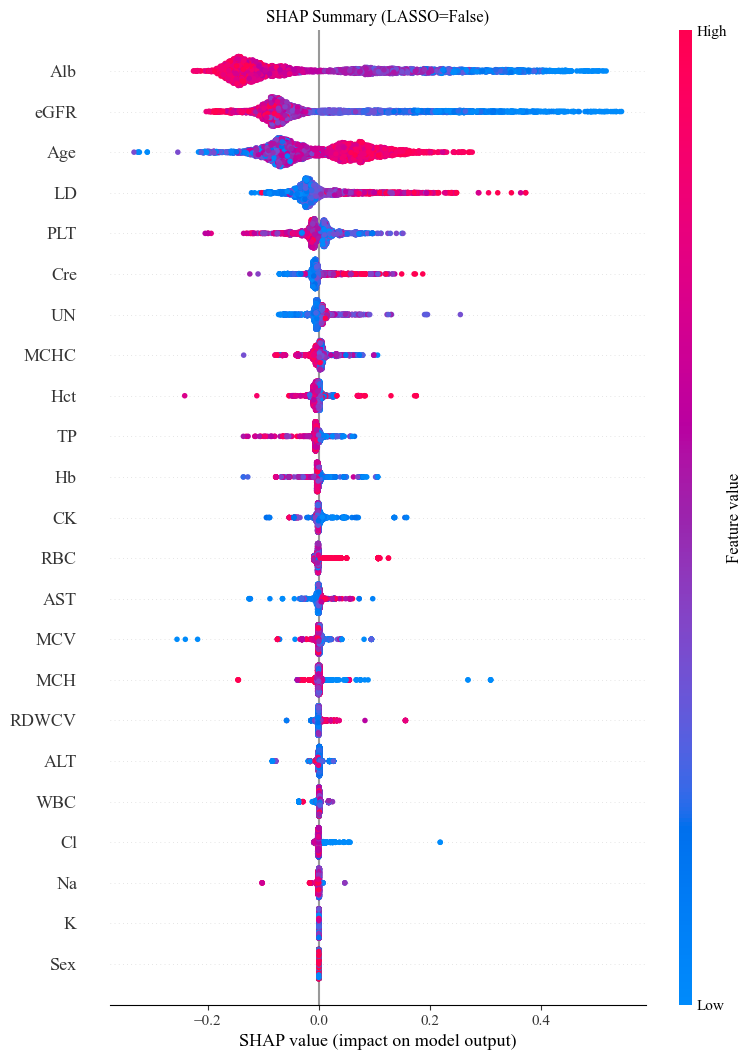


=== Feature Importance (Mean Absolute SHAP) ===


,Feature,Mean_Abs_SHAP
0,Alb,0.149523
1,eGFR,0.110122
2,Age,0.074214
3,LD,0.037784
4,PLT,0.019491
5,Cre,0.014428
6,UN,0.010094
7,MCHC,0.009521
8,Hct,0.006391
9,TP,0.005815


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import math
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, 
                             classification_report, f1_score)
from sklearn.calibration import calibration_curve

# フォント設定 (論文用にTimes New Roman)
plt.rcParams['font.family'] = 'Times New Roman'
random_seed = 1

# ==========================================
# 1. 設定エリア (ここを変更してください)
# ==========================================
# ★ 査読対応用スイッチ
# False = 全変数を決定木に投入（査読者推奨・Plan A）
# True  = LASSOで変数選択してから決定木（元の論文・Plan B）
USE_LASSO = False 

# ファイルパス
INTERNAL_DATA_PATH = "GUdata3.csv"
EXTERNAL_DATA_PATH = '/Users/ishidahidekazu/Library/Mobile Documents/com~apple~CloudDocs/Study/DSS/npj Digital Medicine/Ex/ExData.csv'

# ==========================================
# 2. 統計関数定義 (95% CI計算用)
# ==========================================
def wilson_ci(x, n, alpha=0.05):
    """Wilson score interval for binomial proportion"""
    if n == 0: return (np.nan, np.nan)
    z = abs(stats.norm.ppf(alpha/2))
    phat = x / n
    denom = 1 + z**2/n
    center = (phat + z**2/(2*n)) / denom
    half = z*math.sqrt((phat*(1-phat) + z**2/(4*n))/n) / denom
    return (center - half, center + half)

def delong_roc_ci(y_true, y_score, alpha=0.05, n_boot=2000, seed=42):
    """DeLong CI for AUROC (fallback to bootstrap)"""
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    auc = roc_auc_score(y_true, y_score)
    
    pos = y_score[y_true==1]
    neg = y_score[y_true==0]
    nx, ny = len(pos), len(neg)
    if nx==0 or ny==0: return auc, np.nan, np.nan

    try:
        X_p = pos[:, None]; Y_n = neg[None, :]
        V = (X_p > Y_n).astype(float) + 0.5*(X_p == Y_n).astype(float)
        auc_est = V.mean()
        v10 = V.mean(axis=1); v01 = V.mean(axis=0)
        s10 = np.var(v10, ddof=1); s01 = np.var(v01, ddof=1)
        var = s10/nx + s01/ny
        z = abs(stats.norm.ppf(alpha/2))
        se = math.sqrt(var)
        return auc, max(0.0, auc_est - z*se), min(1.0, auc_est + z*se)
    except:
        rng = np.random.default_rng(seed)
        aucs = []
        for _ in range(n_boot):
            idx = rng.integers(0, len(y_true), len(y_true))
            try: aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
            except: pass
        if not aucs: return auc, np.nan, np.nan
        return auc, np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

def f1_boot_ci(y_true, y_pred, n_boot=2000, seed=42):
    """Bootstrap CI for F1 score"""
    rng = np.random.default_rng(seed)
    scores = []
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        scores.append(f1_score(y_true[idx], y_pred[idx]))
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

def get_metrics_df(y_true, y_prob, thr, cohort_name):
    """主要指標とCIをまとめてDataFrameにする関数"""
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    n = len(y_true)
    
    # Point estimates
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    ppv  = tp/(tp+fp) if (tp+fp)>0 else 0
    npv  = tn/(tn+fn) if (tn+fn)>0 else 0
    acc  = (tp+tn)/n
    f1   = f1_score(y_true, y_pred)
    auc, auc_lo, auc_hi = delong_roc_ci(y_true, y_prob)
    
    # CIs
    sens_ci = wilson_ci(tp, tp+fn)
    spec_ci = wilson_ci(tn, tn+fp)
    ppv_ci  = wilson_ci(tp, tp+fp) if (tp+fp)>0 else (np.nan, np.nan)
    npv_ci  = wilson_ci(tn, tn+fn) if (tn+fn)>0 else (np.nan, np.nan)
    acc_ci  = wilson_ci(tp+tn, n)
    f1_lo, f1_hi = f1_boot_ci(y_true, y_pred)
    
    def fmt(ci): return f"{ci[0]:.3f}–{ci[1]:.3f}"
    
    data = [
        ["AUROC", auc, f"{auc_lo:.3f}–{auc_hi:.3f}", cohort_name],
        ["Sensitivity", sens, fmt(sens_ci), cohort_name],
        ["Specificity", spec, fmt(spec_ci), cohort_name],
        ["PPV", ppv, fmt(ppv_ci), cohort_name],
        ["NPV", npv, fmt(npv_ci), cohort_name],
        ["Accuracy", acc, fmt(acc_ci), cohort_name],
        ["F1", f1, f"{f1_lo:.3f}–{f1_hi:.3f}", cohort_name],
        ["Threshold", thr, "-", cohort_name]
    ]
    return pd.DataFrame(data, columns=["Metric", "Estimate", "95% CI", "Cohort"])

def plot_confusion_matrix_custom(y_true, y_pred, title):
    """ユーザー指定のヒートマップ形式で表示"""
    cf_mat = confusion_matrix(y_true, y_pred)
    class_names = ['<=300 pg/mL', '>300 pg/mL'] 
    plt.figure(figsize=(6, 5))
    sns.heatmap(cf_mat, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted NT-proBNP levels')
    plt.ylabel('Measured NT-proBNP levels')
    plt.title(title)
    plt.show()

# ==========================================
# 3. データ読み込みと前処理
# ==========================================
print(f"Loading Internal Data: {INTERNAL_DATA_PATH}")
df = pd.read_csv(INTERNAL_DATA_PATH)
if "Unnamed: 0" in df.columns: df.set_index("Unnamed: 0", inplace=True)

# ターゲット作成
df["NPB300"] = pd.cut(df["NTproBNP"], bins=[-float("inf"), 300, float("inf")], labels=[0,1])
y = df["NPB300"].astype(int)

# 変数セット作成 (NTproBNPは除外)
X_raw = df.drop(['NTproBNP','NPB300'], axis="columns")

# Train/Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=random_seed, stratify=y
)

# 標準化 (LASSO用。決定木には必須ではないが、比較の一貫性のため保持または非保持を選択可)
# ここでは「決定木には生データを入れたほうが解釈しやすい」ため、
# LASSOにだけ標準化データを使い、Treeには生データ(または選択された変数の生データ)を使います。
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_raw)
# (TestデータはLASSOの係数適用時のみ標準化が必要だが、今回は変数選択にのみLASSOを使うため、以降は生データXを使用)

# ==========================================
# 4. 変数選択 (LASSO vs All)
# ==========================================
features_to_use = list(X_train_raw.columns)

if USE_LASSO:
    print("\n[Method] LASSO Feature Selection is ON.")
    # LassoCVで変数選択
    lasso = LassoCV(cv=10, random_state=random_seed, n_jobs=-1)
    lasso.fit(X_train_std, y_train)
    print(f"Lasso Alpha: {lasso.alpha_}")
    
    # 係数が閾値以上の変数を抽出
    coef_series = pd.Series(lasso.coef_, index=X_train_raw.columns)
    features_to_use = coef_series[abs(coef_series) > 1e-7].index.tolist()
    
    # 元のコードにあった「手動除外(Hb, Hctなど)」を適用したい場合はここで除外
    manual_drop = ["RBC","Hb","Hct","MCH"]
    # features_to_use = [f for f in features_to_use if f not in manual_drop] # 必要ならコメントアウト解除
    
    print(f"Selected {len(features_to_use)} features by LASSO: {features_to_use}")
    
else:
    print("\n[Method] LASSO Feature Selection is OFF (Using All Variables).")
    # 全変数を使用 (Hb, Hctなども含まれる)
    print(f"Using all {len(features_to_use)} features.")

# 決定木用のデータセットを作成
X_train = X_train_raw[features_to_use]
X_test = X_test_raw[features_to_use]

# ==========================================
# 5. モデル構築 (GridSearch & Decision Tree)
# ==========================================
print("\n--- Training Decision Tree ---")
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10]
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=random_seed), 
                           param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("The best hyperparameters:", grid_search.best_params_)

# 決定木の可視化
plt.figure(figsize=(20, 10))
plot_tree(best_model, filled=True, feature_names=features_to_use, 
          class_names=['<=300', '>300'], rounded=True, proportion=False)
plt.title(f"Decision Tree (LASSO={USE_LASSO})")
plt.show()

# ルールのテキスト表示
print(export_text(best_model, feature_names=features_to_use))

# ==========================================
# 6. 内部検証 (Train & Test)
# ==========================================
print("\n--- Internal Evaluation ---")

# 閾値決定: Trainデータで感度(Sensitivity) >= 0.90 を満たす最大特異度の閾値を探す
y_train_prob = best_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_train_prob)

cand_mask = tpr >= 0.90
if cand_mask.sum() > 0:
    # 候補の中で 1-FPR (Specificity) が最大のインデックス
    best_idx = np.argmin(fpr[cand_mask])
    # cand_maskで絞り込んだ中でのインデックスなので、元のthresholdsに対応させる必要がある
    # np.whereを使うのが確実
    indices = np.where(cand_mask)[0]
    final_idx = indices[best_idx]
    thr_i = thresholds[final_idx]
else:
    thr_i = 0.5

print(f"Threshold determined on Train (Sens>=0.90): {thr_i:.6f}")

# --- Train評価 ---
y_train_pred = (y_train_prob >= thr_i).astype(int)
plot_confusion_matrix_custom(y_train, y_train_pred, 'Confusion Matrix on the training dataset')
print("Classification Report (Train):")
print(classification_report(y_train, y_train_pred, target_names=['<=300 pg/mL','>300 pg/mL']))

# --- Test評価 ---
y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= thr_i).astype(int)

plot_confusion_matrix_custom(y_test, y_test_pred, 'Confusion Matrix on the test dataset')
print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=['<=300 pg/mL','>300 pg/mL']))

# ROC Curve (Test)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
auc_test = roc_auc_score(y_test, y_test_prob)
plt.figure()
plt.plot(fpr_test, tpr_test, color='blue', lw=2, label=f'ROC curve (area = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) - Test')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# ==========================================
# 7. 外部検証 (External Validation)
# ==========================================
print("\n--- External Validation ---")
try:
    df_ext = pd.read_csv(EXTERNAL_DATA_PATH)
    if "SQ" in df_ext.columns: df_ext.set_index("SQ", inplace=True)
    
    # 変数とターゲットの準備
    X_ext = df_ext[features_to_use] # モデルと同じ変数のみ抽出
    y_ext = df_ext["NPB300"].astype(int)
    
    # 予測 (内部で決めた閾値 thr_i を使用)
    y_ext_prob = best_model.predict_proba(X_ext)[:, 1]
    y_ext_pred = (y_ext_prob >= thr_i).astype(int)
    
    # Confusion Matrix
    plot_confusion_matrix_custom(y_ext, y_ext_pred, 'Confusion Matrix on the external dataset')
    print("Classification Report (External):")
    print(classification_report(y_ext, y_ext_pred, target_names=['<=300 pg/mL','>300 pg/mL']))

    # ROC Curve
    fpr_ext, tpr_ext, _ = roc_curve(y_ext, y_ext_prob)
    auc_ext = roc_auc_score(y_ext, y_ext_prob)
    plt.figure()
    plt.plot(fpr_ext, tpr_ext, color='blue', lw=2, label=f'ROC curve (area = {auc_ext:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.title('Receiver Operating Characteristic (ROC) - External')
    plt.legend(loc="lower right")
    plt.show()

    # --- 総合結果テーブル (CI付き) ---
    df_metrics_train = get_metrics_df(y_train, y_train_prob, thr_i, "Internal Train")
    df_metrics_test  = get_metrics_df(y_test, y_test_prob, thr_i, "Internal Test")
    df_metrics_ext   = get_metrics_df(y_ext, y_ext_prob, thr_i, "External Validation")
    
    df_all_metrics = pd.concat([df_metrics_train, df_metrics_test, df_metrics_ext], ignore_index=True)
    print("\n=== Performance Metrics with 95% CIs ===")
    display(df_all_metrics)

    # --- Calibration Plot ---
    prob_true, prob_pred = calibration_curve(y_ext, y_ext_prob, n_bins=10)
    plt.figure(figsize=(5, 5))
    plt.plot(prob_pred, prob_true, 'o-', label='Decision Tree')
    plt.plot([0,1], [0,1], '--', color='gray')
    plt.xlabel('Predicted probability')
    plt.ylabel('Observed frequency')
    plt.title('Calibration plot – External validation')
    plt.legend()
    plt.show()

    # --- Decision Curve Analysis (DCA) ---
    def net_benefit(y_true, y_prob, thr):
        pred = (y_prob >= thr)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        n = len(y_true)
        return (tp / n) - (fp / n) * (thr / (1 - thr))

    thresholds_dca = np.linspace(0.01, 0.99, 100)
    nb_model = [net_benefit(y_ext, y_ext_prob, t) for t in thresholds_dca]
    nb_all   = [y_ext.mean() - (1 - y_ext.mean()) * (t/(1-t)) for t in thresholds_dca]
    nb_none  = np.zeros_like(thresholds_dca)

    plt.figure(figsize=(6, 5))
    plt.plot(thresholds_dca, nb_model, label='Model')
    plt.plot(thresholds_dca, nb_all, '--', label='Treat-all')
    plt.axhline(0, color='gray', ls=':')
    plt.xlabel('Threshold probability')
    plt.ylabel('Net benefit')
    plt.title('Decision Curve – External cohort')
    plt.ylim(-0.05, max(nb_model + nb_all)*1.1)
    plt.xlim(0, 1.0)
    plt.legend()
    plt.show()
    
    # --- Subgroup Analysis (Major Groups) ---
    # データセットにカラムが存在する場合のみ実行
    subgroups = {
        'Age < 65': df_ext['Age'] < 65,
        'Age >= 65': df_ext['Age'] >= 65,
        'eGFR < 60': df_ext['eGFR'] < 60,
        'eGFR >= 60': df_ext['eGFR'] >= 60,
        # 'Male': df_ext['Sex'] == 1,   # 必要に応じて有効化
        # 'Female': df_ext['Sex'] == 0
    }
    
    sg_results = []
    for name, mask in subgroups.items():
        if mask.sum() > 30: # サンプル数確保
            y_sg = y_ext[mask]
            p_sg = y_ext_prob[mask]
            auc_sg = roc_auc_score(y_sg, p_sg)
            f1_sg = f1_score(y_sg, (p_sg >= thr_i).astype(int))
            sg_results.append({'Subgroup': name, 'N': mask.sum(), 'AUROC': auc_sg, 'F1': f1_sg})
    
    if sg_results:
        print("\n=== Subgroup Analysis (External) ===")
        display(pd.DataFrame(sg_results))

except Exception as e:
    print(f"External validation skipped or error: {e}")

# ==========================================
# 8. SHAP Analysis (Graph Fix)
# ==========================================
print("\n--- SHAP Analysis ---")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Binary classification handling
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
else:
    if shap_values.ndim == 3:
        shap_vals_to_plot = shap_values[:,:,1]
    else:
        shap_vals_to_plot = shap_values

# ★ここが修正ポイント: 変数の総数を取得して max_display に設定
num_features = X_test.shape[1]

plt.figure()
# max_display=num_features とすることで、隠れることなく全変数が表示されます
shap.summary_plot(shap_vals_to_plot, X_test, max_display=num_features, show=False)
plt.title(f"SHAP Summary (LASSO={USE_LASSO})")
plt.tight_layout()
plt.show()

# ==========================================
# 9. SHAP Importance List (List Fix)
# ==========================================
import pandas as pd
import numpy as np

# 平均絶対SHAP値の計算
mean_abs_shap = np.abs(shap_vals_to_plot).mean(axis=0)

# DataFrame作成
df_shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': mean_abs_shap
})

# ソート
df_shap_importance = df_shap_importance.sort_values(by='Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

print("\n=== Feature Importance (Mean Absolute SHAP) ===")
# pandasの表示設定を変更して全行表示する
with pd.option_context('display.max_rows', None): 
    display(df_shap_importance)

In [2]:
# ==========================================
# 9. SHAP Importance List (Coefficient-like view)
# ==========================================
import pandas as pd
import numpy as np

# 1. 各変数のSHAP絶対値の平均を計算（これが重要度になります）
# shap_vals_to_plot: (サンプル数, 特徴量数) の配列
mean_abs_shap = np.abs(shap_vals_to_plot).mean(axis=0)

# 2. DataFrameにまとめる
df_shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': mean_abs_shap
})

# 3. 重要度順にソート（降順）
df_shap_importance = df_shap_importance.sort_values(by='Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

# 4. 表示
print("\n=== Feature Importance (Mean Absolute SHAP) ===")
display(df_shap_importance)

# 5. CSV保存（必要であれば）
# df_shap_importance.to_csv("shap_feature_importance.csv", index=False)


=== Feature Importance (Mean Absolute SHAP) ===


,Feature,Mean_Abs_SHAP
0,Alb,0.149523
1,eGFR,0.110122
2,Age,0.074214
3,LD,0.037784
4,PLT,0.019491
5,Cre,0.014428
6,UN,0.010094
7,MCHC,0.009521
8,Hct,0.006391
9,TP,0.005815



--- Generating Figure 2 (Simplified Tree) ---


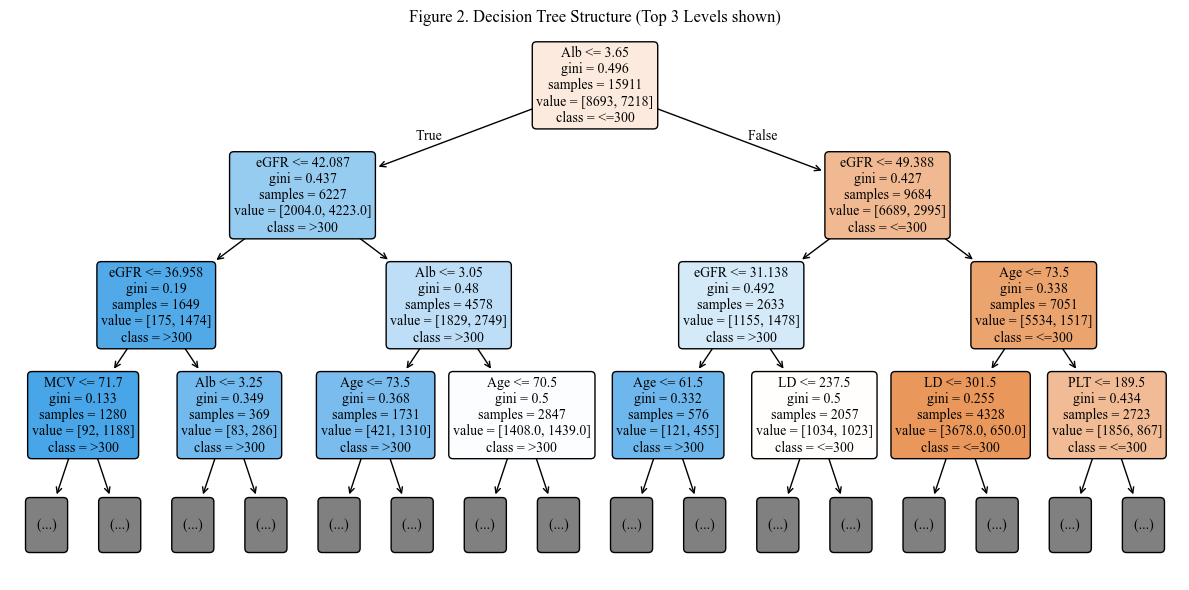


--- Generating Supplementary Table (Full Rules) ---
Total Rules extracted: 111


,Rule_ID,Conditions (IF),Prediction (THEN),Probability,Sample_Count
0,1,Alb <= 3.65 AND eGFR <= 42.09 AND eGFR <= 36.96 AND MCV <= 71.70,<=300,58.33%,1
1,2,Alb <= 3.65 AND eGFR <= 42.09 AND eGFR <= 36.96 AND MCV > 71.70 AND Alb <= 3.05 AND Cre <= 1.34 ...,>300,54.55%,1
2,3,Alb <= 3.65 AND eGFR <= 42.09 AND eGFR <= 36.96 AND MCV > 71.70 AND Alb <= 3.05 AND Cre <= 1.34 ...,>300,100.00%,1
3,4,Alb <= 3.65 AND eGFR <= 42.09 AND eGFR <= 36.96 AND MCV > 71.70 AND Alb <= 3.05 AND Cre > 1.34 A...,>300,95.77%,1
4,5,Alb <= 3.65 AND eGFR <= 42.09 AND eGFR <= 36.96 AND MCV > 71.70 AND Alb <= 3.05 AND Cre > 1.34 A...,>300,99.77%,1


Saved: Supplementary_Table_Rules.csv


In [4]:
# ==========================================
# 10. Figure 2: Simplified Tree (Depth=3)
# ==========================================
print("\n--- Generating Figure 2 (Simplified Tree) ---")

plt.figure(figsize=(12, 6)) # 横長で見やすく
plot_tree(best_model, 
          filled=True, 
          feature_names=features_to_use, 
          class_names=['<=300', '>300'], 
          rounded=True, 
          proportion=False, 
          max_depth=3,      # ★ここが重要：表示を深さ3で止める
          fontsize=10)      # フォントサイズ調整
plt.title("Figure 2. Decision Tree Structure (Top 3 Levels shown)")
plt.tight_layout()
plt.savefig("Figure2_Simplified_Tree.png", dpi=300) # 高画質保存
plt.show()

# ==========================================
# 11. Supplementary Table: Full Rules Export
# ==========================================
print("\n--- Generating Supplementary Table (Full Rules) ---")

def get_tree_rules_dataframe(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]
    
    paths = []
    
    def recurse(node, path_str):
        if tree_.feature[node] != -2: # Not a leaf node
            name = feature_name[node]
            threshold = tree_.threshold[node]
            # Left child (<=)
            recurse(tree_.children_left[node], path_str + [f"{name} <= {threshold:.2f}"])
            # Right child (>)
            recurse(tree_.children_right[node], path_str + [f"{name} > {threshold:.2f}"])
        else: # Leaf node
            # 予測クラスの決定
            value = tree_.value[node][0]
            class_idx = np.argmax(value)
            pred_class = class_names[class_idx]
            
            # 確率（Probability）の計算 (オプション)
            prob = value[class_idx] / np.sum(value)
            
            # 条件を結合
            condition_text = " AND ".join(path_str)
            
            paths.append({
                "Rule_ID": len(paths) + 1,
                "Conditions (IF)": condition_text,
                "Prediction (THEN)": pred_class,
                "Probability": f"{prob:.2%}",
                "Sample_Count": int(np.sum(value))
            })
    
    recurse(0, [])
    return pd.DataFrame(paths)

# データフレーム作成
df_rules = get_tree_rules_dataframe(best_model, features_to_use, ['<=300', '>300'])

# 表示確認
print(f"Total Rules extracted: {len(df_rules)}")
with pd.option_context('display.max_colwidth', 100):
    display(df_rules.head())

# CSV保存（これをExcelで開いてSupplementary Tableに整形してください）
df_rules.to_csv("Supplementary_Table_Rules.csv", index=False)
print("Saved: Supplementary_Table_Rules.csv")

## Lasso ON

Loading Internal Data: GUdata3.csv

[Method] LASSO Feature Selection is ON.


/Users/ishidahidekazu/.pyenv/versions/miniforge3-4.10.1-5/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.4964588575548987, tolerance: 0.3550677094972486
  model = cd_fast.enet_coordinate_descent_gram(
/Users/ishidahidekazu/.pyenv/versions/miniforge3-4.10.1-5/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.5253999245787782, tolerance: 0.3550677094972486
  model = cd_fast.enet_coordinate_descent_gram(
/Users/ishidahidekazu/.pyenv/versions/miniforge3-4.10.1-5/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.5291664984088129, tolerance: 0.3550677094972486
  model

Lasso Alpha: 0.00020420088942186225
Selected 20 features by LASSO: ['Sex', 'Age', 'Na', 'K', 'Cl', 'TP', 'Alb', 'CK', 'AST', 'ALT', 'LD', 'Cre', 'UN', 'WBC', 'RBC', 'MCV', 'MCH', 'RDWCV', 'PLT', 'eGFR']

--- Training Decision Tree ---
The best hyperparameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5}


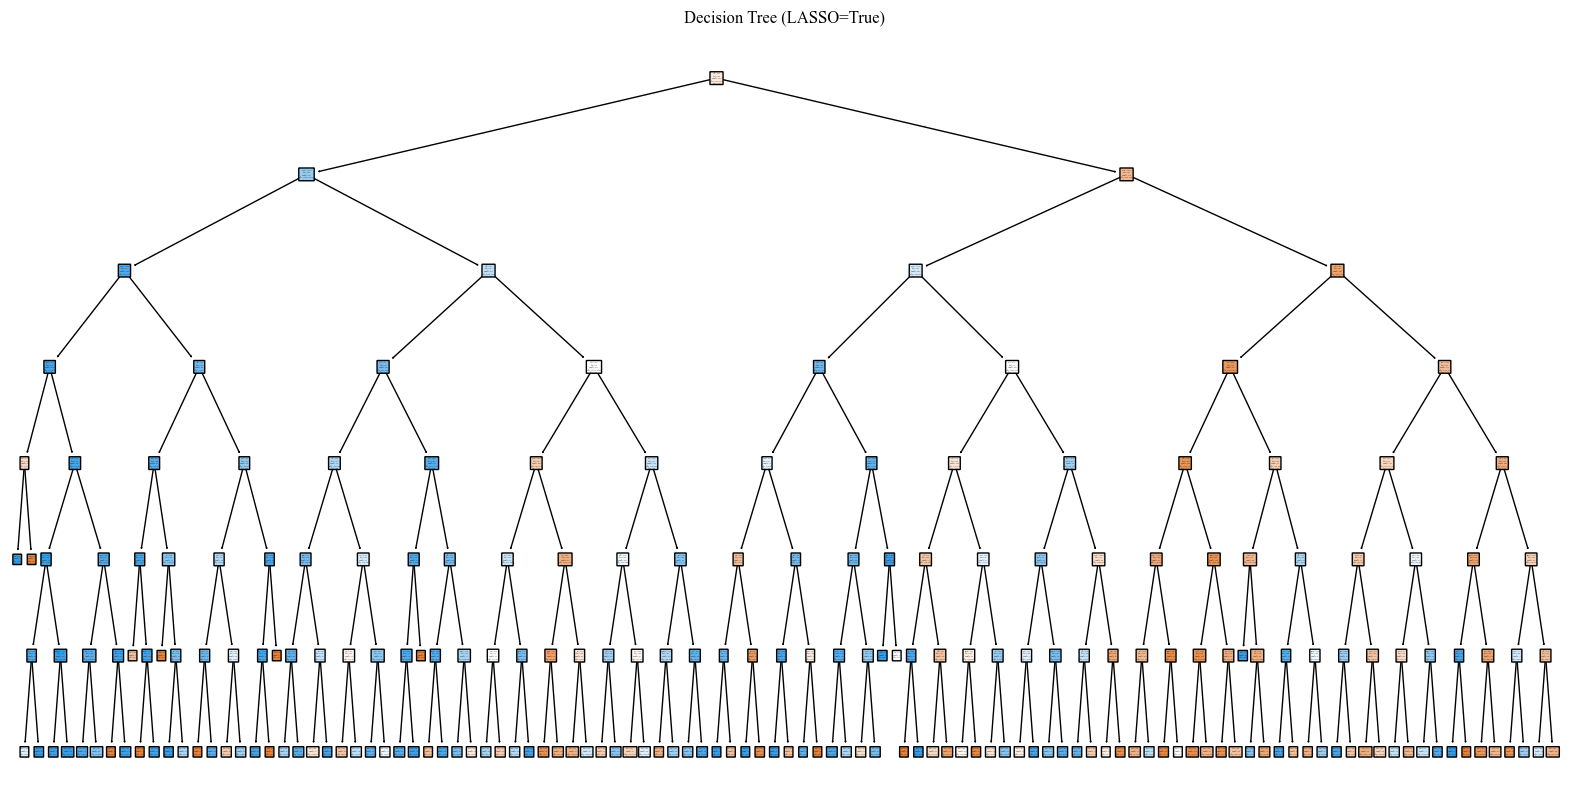

|--- Alb <= 3.65
|   |--- eGFR <= 42.09
|   |   |--- eGFR <= 36.96
|   |   |   |--- MCV <= 71.70
|   |   |   |   |--- CK <= 31.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- CK >  31.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- MCV >  71.70
|   |   |   |   |--- Alb <= 3.05
|   |   |   |   |   |--- Cre <= 1.34
|   |   |   |   |   |   |--- LD <= 188.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- LD >  188.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Cre >  1.34
|   |   |   |   |   |   |--- RDWCV <= 13.35
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- RDWCV >  13.35
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- Alb >  3.05
|   |   |   |   |   |--- Cre <= 1.86
|   |   |   |   |   |   |--- PLT <= 243.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- PLT >  243.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Cre >  1.86
|   |   |   |  

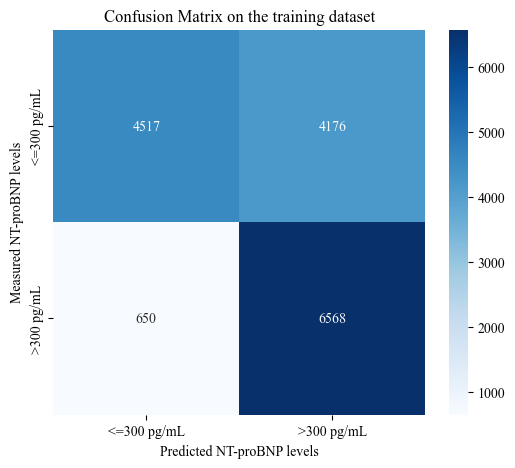

Classification Report (Train):
              precision    recall  f1-score   support

 <=300 pg/mL       0.87      0.52      0.65      8693
  >300 pg/mL       0.61      0.91      0.73      7218

    accuracy                           0.70     15911
   macro avg       0.74      0.71      0.69     15911
weighted avg       0.75      0.70      0.69     15911



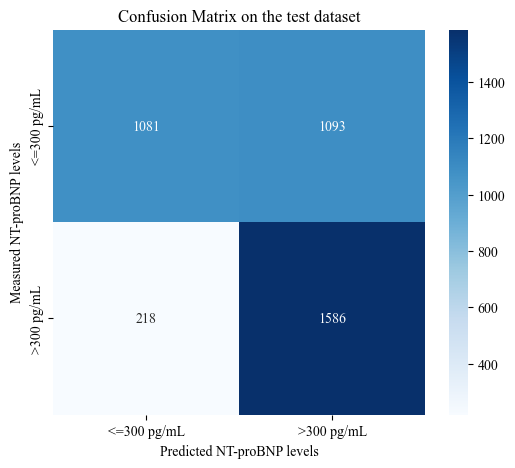

Classification Report (Test):
              precision    recall  f1-score   support

 <=300 pg/mL       0.83      0.50      0.62      2174
  >300 pg/mL       0.59      0.88      0.71      1804

    accuracy                           0.67      3978
   macro avg       0.71      0.69      0.67      3978
weighted avg       0.72      0.67      0.66      3978



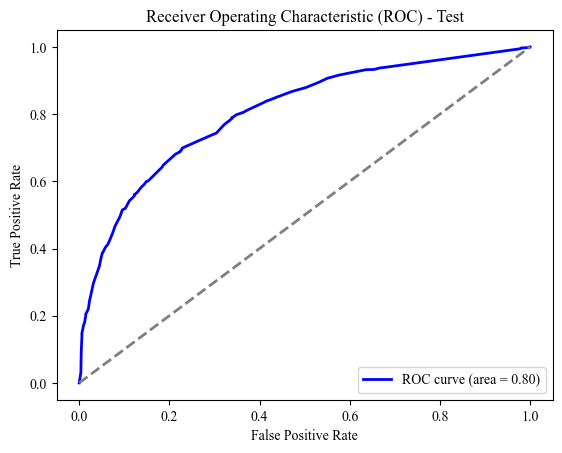


--- External Validation ---


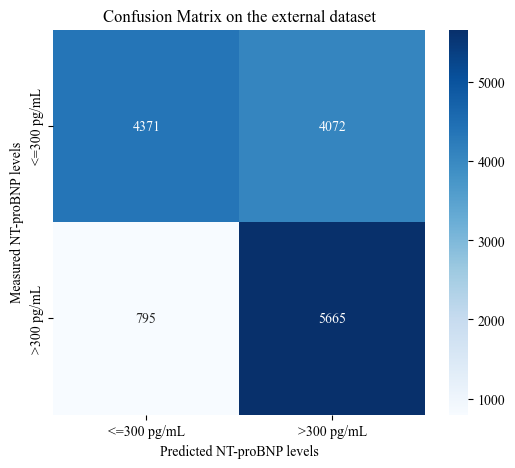

Classification Report (External):
              precision    recall  f1-score   support

 <=300 pg/mL       0.85      0.52      0.64      8443
  >300 pg/mL       0.58      0.88      0.70      6460

    accuracy                           0.67     14903
   macro avg       0.71      0.70      0.67     14903
weighted avg       0.73      0.67      0.67     14903



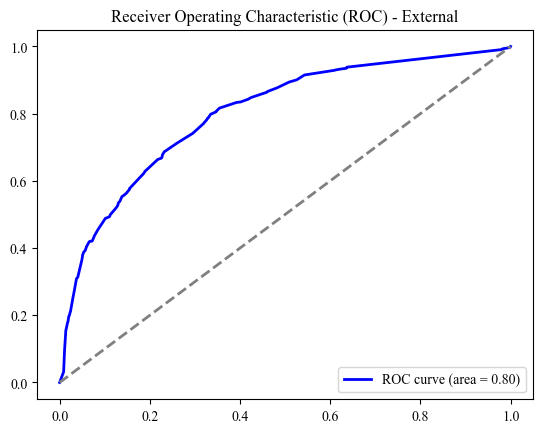


=== Performance Metrics with 95% CIs ===


,Metric,Estimate,95% CI,Cohort
0,AUROC,0.849151,0.843–0.855,Internal Train
1,Sensitivity,0.909947,0.903–0.916,Internal Train
2,Specificity,0.519613,0.509–0.530,Internal Train
3,PPV,0.611318,0.602–0.620,Internal Train
4,NPV,0.874202,0.865–0.883,Internal Train
5,Accuracy,0.696688,0.689–0.704,Internal Train
6,F1,0.731322,0.724–0.738,Internal Train
7,Threshold,0.263158,-,Internal Train
8,AUROC,0.804878,0.791–0.818,Internal Test
9,Sensitivity,0.879157,0.863–0.893,Internal Test


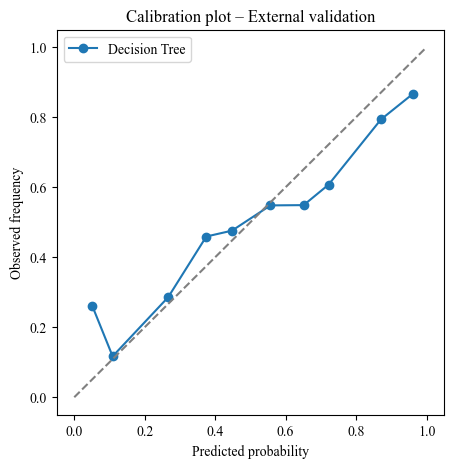

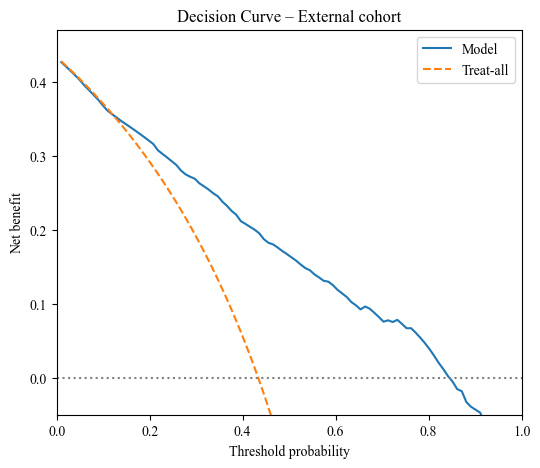


=== Subgroup Analysis (External) ===


,Subgroup,N,AUROC,F1
0,Age < 65,4060,0.787771,0.587349
1,Age >= 65,10843,0.782467,0.721512
2,eGFR < 60,7656,0.773412,0.759119
3,eGFR >= 60,7247,0.774866,0.588816



--- SHAP Analysis ---


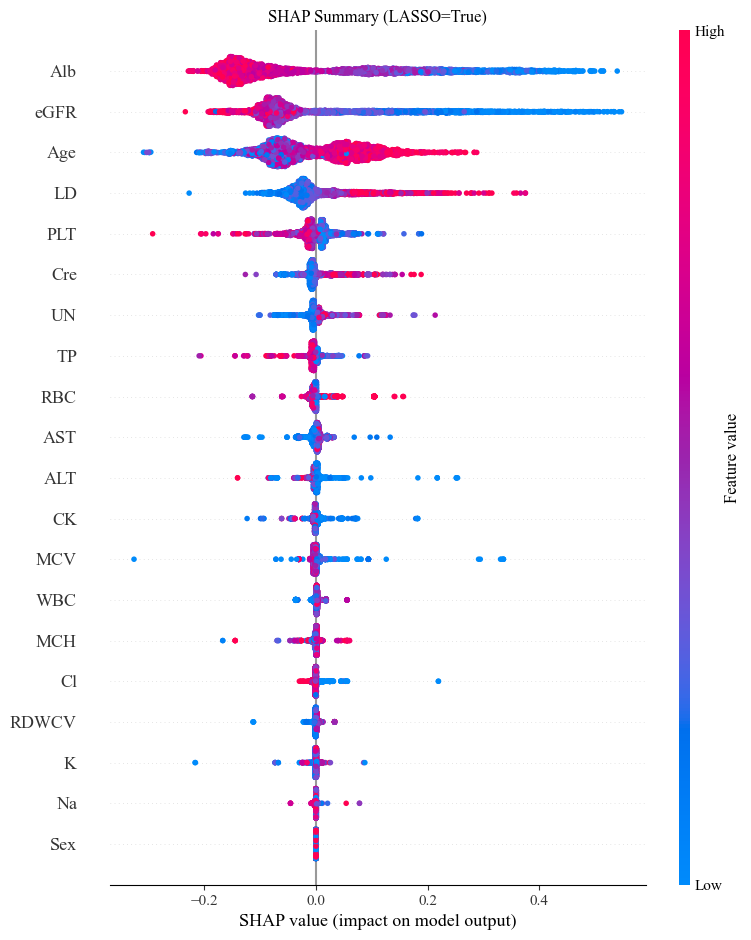

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import math
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, 
                             classification_report, f1_score)
from sklearn.calibration import calibration_curve

# フォント設定 (論文用にTimes New Roman)
plt.rcParams['font.family'] = 'Times New Roman'
random_seed = 1

# ==========================================
# 1. 設定エリア (ここを変更してください)
# ==========================================
# ★ 査読対応用スイッチ
# False = 全変数を決定木に投入（査読者推奨・Plan A）
# True  = LASSOで変数選択してから決定木（元の論文・Plan B）
USE_LASSO = True

# ファイルパス
INTERNAL_DATA_PATH = "GUdata3.csv"
EXTERNAL_DATA_PATH = '/Users/ishidahidekazu/Library/Mobile Documents/com~apple~CloudDocs/Study/DSS/npj Digital Medicine/Ex/ExData.csv'

# ==========================================
# 2. 統計関数定義 (95% CI計算用)
# ==========================================
def wilson_ci(x, n, alpha=0.05):
    """Wilson score interval for binomial proportion"""
    if n == 0: return (np.nan, np.nan)
    z = abs(stats.norm.ppf(alpha/2))
    phat = x / n
    denom = 1 + z**2/n
    center = (phat + z**2/(2*n)) / denom
    half = z*math.sqrt((phat*(1-phat) + z**2/(4*n))/n) / denom
    return (center - half, center + half)

def delong_roc_ci(y_true, y_score, alpha=0.05, n_boot=2000, seed=42):
    """DeLong CI for AUROC (fallback to bootstrap)"""
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    auc = roc_auc_score(y_true, y_score)
    
    pos = y_score[y_true==1]
    neg = y_score[y_true==0]
    nx, ny = len(pos), len(neg)
    if nx==0 or ny==0: return auc, np.nan, np.nan

    try:
        X_p = pos[:, None]; Y_n = neg[None, :]
        V = (X_p > Y_n).astype(float) + 0.5*(X_p == Y_n).astype(float)
        auc_est = V.mean()
        v10 = V.mean(axis=1); v01 = V.mean(axis=0)
        s10 = np.var(v10, ddof=1); s01 = np.var(v01, ddof=1)
        var = s10/nx + s01/ny
        z = abs(stats.norm.ppf(alpha/2))
        se = math.sqrt(var)
        return auc, max(0.0, auc_est - z*se), min(1.0, auc_est + z*se)
    except:
        rng = np.random.default_rng(seed)
        aucs = []
        for _ in range(n_boot):
            idx = rng.integers(0, len(y_true), len(y_true))
            try: aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
            except: pass
        if not aucs: return auc, np.nan, np.nan
        return auc, np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

def f1_boot_ci(y_true, y_pred, n_boot=2000, seed=42):
    """Bootstrap CI for F1 score"""
    rng = np.random.default_rng(seed)
    scores = []
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        scores.append(f1_score(y_true[idx], y_pred[idx]))
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

def get_metrics_df(y_true, y_prob, thr, cohort_name):
    """主要指標とCIをまとめてDataFrameにする関数"""
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    n = len(y_true)
    
    # Point estimates
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    ppv  = tp/(tp+fp) if (tp+fp)>0 else 0
    npv  = tn/(tn+fn) if (tn+fn)>0 else 0
    acc  = (tp+tn)/n
    f1   = f1_score(y_true, y_pred)
    auc, auc_lo, auc_hi = delong_roc_ci(y_true, y_prob)
    
    # CIs
    sens_ci = wilson_ci(tp, tp+fn)
    spec_ci = wilson_ci(tn, tn+fp)
    ppv_ci  = wilson_ci(tp, tp+fp) if (tp+fp)>0 else (np.nan, np.nan)
    npv_ci  = wilson_ci(tn, tn+fn) if (tn+fn)>0 else (np.nan, np.nan)
    acc_ci  = wilson_ci(tp+tn, n)
    f1_lo, f1_hi = f1_boot_ci(y_true, y_pred)
    
    def fmt(ci): return f"{ci[0]:.3f}–{ci[1]:.3f}"
    
    data = [
        ["AUROC", auc, f"{auc_lo:.3f}–{auc_hi:.3f}", cohort_name],
        ["Sensitivity", sens, fmt(sens_ci), cohort_name],
        ["Specificity", spec, fmt(spec_ci), cohort_name],
        ["PPV", ppv, fmt(ppv_ci), cohort_name],
        ["NPV", npv, fmt(npv_ci), cohort_name],
        ["Accuracy", acc, fmt(acc_ci), cohort_name],
        ["F1", f1, f"{f1_lo:.3f}–{f1_hi:.3f}", cohort_name],
        ["Threshold", thr, "-", cohort_name]
    ]
    return pd.DataFrame(data, columns=["Metric", "Estimate", "95% CI", "Cohort"])

def plot_confusion_matrix_custom(y_true, y_pred, title):
    """ユーザー指定のヒートマップ形式で表示"""
    cf_mat = confusion_matrix(y_true, y_pred)
    class_names = ['<=300 pg/mL', '>300 pg/mL'] 
    plt.figure(figsize=(6, 5))
    sns.heatmap(cf_mat, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted NT-proBNP levels')
    plt.ylabel('Measured NT-proBNP levels')
    plt.title(title)
    plt.show()

# ==========================================
# 3. データ読み込みと前処理
# ==========================================
print(f"Loading Internal Data: {INTERNAL_DATA_PATH}")
df = pd.read_csv(INTERNAL_DATA_PATH)
if "Unnamed: 0" in df.columns: df.set_index("Unnamed: 0", inplace=True)

# ターゲット作成
df["NPB300"] = pd.cut(df["NTproBNP"], bins=[-float("inf"), 300, float("inf")], labels=[0,1])
y = df["NPB300"].astype(int)

# 変数セット作成 (NTproBNPは除外)
X_raw = df.drop(['NTproBNP','NPB300'], axis="columns")

# Train/Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=random_seed, stratify=y
)

# 標準化 (LASSO用。決定木には必須ではないが、比較の一貫性のため保持または非保持を選択可)
# ここでは「決定木には生データを入れたほうが解釈しやすい」ため、
# LASSOにだけ標準化データを使い、Treeには生データ(または選択された変数の生データ)を使います。
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_raw)
# (TestデータはLASSOの係数適用時のみ標準化が必要だが、今回は変数選択にのみLASSOを使うため、以降は生データXを使用)

# ==========================================
# 4. 変数選択 (LASSO vs All)
# ==========================================
features_to_use = list(X_train_raw.columns)

if USE_LASSO:
    print("\n[Method] LASSO Feature Selection is ON.")
    # LassoCVで変数選択
    lasso = LassoCV(cv=10, random_state=random_seed, n_jobs=-1)
    lasso.fit(X_train_std, y_train)
    print(f"Lasso Alpha: {lasso.alpha_}")
    
    # 係数が閾値以上の変数を抽出
    coef_series = pd.Series(lasso.coef_, index=X_train_raw.columns)
    features_to_use = coef_series[abs(coef_series) > 1e-7].index.tolist()
    
    # 元のコードにあった「手動除外(Hb, Hctなど)」を適用したい場合はここで除外
    manual_drop = ["RBC","Hb","Hct","MCH"]
    # features_to_use = [f for f in features_to_use if f not in manual_drop] # 必要ならコメントアウト解除
    
    print(f"Selected {len(features_to_use)} features by LASSO: {features_to_use}")
    
else:
    print("\n[Method] LASSO Feature Selection is OFF (Using All Variables).")
    # 全変数を使用 (Hb, Hctなども含まれる)
    print(f"Using all {len(features_to_use)} features.")

# 決定木用のデータセットを作成
X_train = X_train_raw[features_to_use]
X_test = X_test_raw[features_to_use]

# ==========================================
# 5. モデル構築 (GridSearch & Decision Tree)
# ==========================================
print("\n--- Training Decision Tree ---")
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10]
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=random_seed), 
                           param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("The best hyperparameters:", grid_search.best_params_)

# 決定木の可視化
plt.figure(figsize=(20, 10))
plot_tree(best_model, filled=True, feature_names=features_to_use, 
          class_names=['<=300', '>300'], rounded=True, proportion=False)
plt.title(f"Decision Tree (LASSO={USE_LASSO})")
plt.show()

# ルールのテキスト表示
print(export_text(best_model, feature_names=features_to_use))

# ==========================================
# 6. 内部検証 (Train & Test)
# ==========================================
print("\n--- Internal Evaluation ---")

# 閾値決定: Trainデータで感度(Sensitivity) >= 0.90 を満たす最大特異度の閾値を探す
y_train_prob = best_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_train_prob)

cand_mask = tpr >= 0.90
if cand_mask.sum() > 0:
    # 候補の中で 1-FPR (Specificity) が最大のインデックス
    best_idx = np.argmin(fpr[cand_mask])
    # cand_maskで絞り込んだ中でのインデックスなので、元のthresholdsに対応させる必要がある
    # np.whereを使うのが確実
    indices = np.where(cand_mask)[0]
    final_idx = indices[best_idx]
    thr_i = thresholds[final_idx]
else:
    thr_i = 0.5

print(f"Threshold determined on Train (Sens>=0.90): {thr_i:.6f}")

# --- Train評価 ---
y_train_pred = (y_train_prob >= thr_i).astype(int)
plot_confusion_matrix_custom(y_train, y_train_pred, 'Confusion Matrix on the training dataset')
print("Classification Report (Train):")
print(classification_report(y_train, y_train_pred, target_names=['<=300 pg/mL','>300 pg/mL']))

# --- Test評価 ---
y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= thr_i).astype(int)

plot_confusion_matrix_custom(y_test, y_test_pred, 'Confusion Matrix on the test dataset')
print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=['<=300 pg/mL','>300 pg/mL']))

# ROC Curve (Test)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
auc_test = roc_auc_score(y_test, y_test_prob)
plt.figure()
plt.plot(fpr_test, tpr_test, color='blue', lw=2, label=f'ROC curve (area = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) - Test')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# ==========================================
# 7. 外部検証 (External Validation)
# ==========================================
print("\n--- External Validation ---")
try:
    df_ext = pd.read_csv(EXTERNAL_DATA_PATH)
    if "SQ" in df_ext.columns: df_ext.set_index("SQ", inplace=True)
    
    # 変数とターゲットの準備
    X_ext = df_ext[features_to_use] # モデルと同じ変数のみ抽出
    y_ext = df_ext["NPB300"].astype(int)
    
    # 予測 (内部で決めた閾値 thr_i を使用)
    y_ext_prob = best_model.predict_proba(X_ext)[:, 1]
    y_ext_pred = (y_ext_prob >= thr_i).astype(int)
    
    # Confusion Matrix
    plot_confusion_matrix_custom(y_ext, y_ext_pred, 'Confusion Matrix on the external dataset')
    print("Classification Report (External):")
    print(classification_report(y_ext, y_ext_pred, target_names=['<=300 pg/mL','>300 pg/mL']))

    # ROC Curve
    fpr_ext, tpr_ext, _ = roc_curve(y_ext, y_ext_prob)
    auc_ext = roc_auc_score(y_ext, y_ext_prob)
    plt.figure()
    plt.plot(fpr_ext, tpr_ext, color='blue', lw=2, label=f'ROC curve (area = {auc_ext:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.title('Receiver Operating Characteristic (ROC) - External')
    plt.legend(loc="lower right")
    plt.show()

    # --- 総合結果テーブル (CI付き) ---
    df_metrics_train = get_metrics_df(y_train, y_train_prob, thr_i, "Internal Train")
    df_metrics_test  = get_metrics_df(y_test, y_test_prob, thr_i, "Internal Test")
    df_metrics_ext   = get_metrics_df(y_ext, y_ext_prob, thr_i, "External Validation")
    
    df_all_metrics = pd.concat([df_metrics_train, df_metrics_test, df_metrics_ext], ignore_index=True)
    print("\n=== Performance Metrics with 95% CIs ===")
    display(df_all_metrics)

    # --- Calibration Plot ---
    prob_true, prob_pred = calibration_curve(y_ext, y_ext_prob, n_bins=10)
    plt.figure(figsize=(5, 5))
    plt.plot(prob_pred, prob_true, 'o-', label='Decision Tree')
    plt.plot([0,1], [0,1], '--', color='gray')
    plt.xlabel('Predicted probability')
    plt.ylabel('Observed frequency')
    plt.title('Calibration plot – External validation')
    plt.legend()
    plt.show()

    # --- Decision Curve Analysis (DCA) ---
    def net_benefit(y_true, y_prob, thr):
        pred = (y_prob >= thr)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        n = len(y_true)
        return (tp / n) - (fp / n) * (thr / (1 - thr))

    thresholds_dca = np.linspace(0.01, 0.99, 100)
    nb_model = [net_benefit(y_ext, y_ext_prob, t) for t in thresholds_dca]
    nb_all   = [y_ext.mean() - (1 - y_ext.mean()) * (t/(1-t)) for t in thresholds_dca]
    nb_none  = np.zeros_like(thresholds_dca)

    plt.figure(figsize=(6, 5))
    plt.plot(thresholds_dca, nb_model, label='Model')
    plt.plot(thresholds_dca, nb_all, '--', label='Treat-all')
    plt.axhline(0, color='gray', ls=':')
    plt.xlabel('Threshold probability')
    plt.ylabel('Net benefit')
    plt.title('Decision Curve – External cohort')
    plt.ylim(-0.05, max(nb_model + nb_all)*1.1)
    plt.xlim(0, 1.0)
    plt.legend()
    plt.show()
    
    # --- Subgroup Analysis (Major Groups) ---
    # データセットにカラムが存在する場合のみ実行
    subgroups = {
        'Age < 65': df_ext['Age'] < 65,
        'Age >= 65': df_ext['Age'] >= 65,
        'eGFR < 60': df_ext['eGFR'] < 60,
        'eGFR >= 60': df_ext['eGFR'] >= 60,
        # 'Male': df_ext['Sex'] == 1,   # 必要に応じて有効化
        # 'Female': df_ext['Sex'] == 0
    }
    
    sg_results = []
    for name, mask in subgroups.items():
        if mask.sum() > 30: # サンプル数確保
            y_sg = y_ext[mask]
            p_sg = y_ext_prob[mask]
            auc_sg = roc_auc_score(y_sg, p_sg)
            f1_sg = f1_score(y_sg, (p_sg >= thr_i).astype(int))
            sg_results.append({'Subgroup': name, 'N': mask.sum(), 'AUROC': auc_sg, 'F1': f1_sg})
    
    if sg_results:
        print("\n=== Subgroup Analysis (External) ===")
        display(pd.DataFrame(sg_results))

except Exception as e:
    print(f"External validation skipped or error: {e}")

# ==========================================
# 8. SHAP Analysis
# ==========================================
print("\n--- SHAP Analysis ---")
# TreeExplainerを使用 (決定木モデルに最適)
explainer = shap.TreeExplainer(best_model)
# TestデータのSHAP値を計算
shap_values = explainer.shap_values(X_test)

# shap_valuesはリスト[class0, class1]で返る場合と、arrayで返る場合があります
if isinstance(shap_values, list):
    # クラス1 (>300) に対する寄与度を使用
    shap_vals_to_plot = shap_values[1]
else:
    # 2値分類で1つのarrayが返る場合（XGBoostなど）の安全策だがTreeではリストが多い
    if shap_values.ndim == 3:
        shap_vals_to_plot = shap_values[:,:,1]
    else:
        shap_vals_to_plot = shap_values

plt.figure()
shap.summary_plot(shap_vals_to_plot, X_test, show=False)
plt.title(f"SHAP Summary (LASSO={USE_LASSO})")
plt.tight_layout()
plt.show()